# Gradient Descent en una superficie 3D

Este notebook muestra una simulacion de `gradient descent` sobre una funcion de costo `J(theta0, theta1)`.

El objetivo es visualizar dos cosas:

- la forma de la superficie,
- y el camino que siguen los parametros hasta bajar hacia un minimo.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')

## 1. Funcion de costo y gradiente

Usamos una funcion suave con ondulaciones para que la trayectoria sea facil de observar:

$$
J(\theta_0, \theta_1) = \sin(3\theta_0)\cos(3\theta_1) + (\theta_0 - 0.3)^2 + (\theta_1 - 0.6)^2
$$

Tambien calculamos su gradiente analitico.

In [7]:
def cost(theta0, theta1):
    return np.sin(3 * theta0) * np.cos(3 * theta1) + (theta0 - 0.3) ** 2 + (theta1 - 0.6) ** 2

def gradient(theta0, theta1):
    dtheta0 = 3 * np.cos(3 * theta0) * np.cos(3 * theta1) + 2 * (theta0 - 0.3)
    dtheta1 = -3 * np.sin(3 * theta0) * np.sin(3 * theta1) + 2 * (theta1 - 0.6)
    return np.array([dtheta0, dtheta1])

## 2. Malla de puntos para dibujar la superficie

In [8]:
theta0_values = np.linspace(0.0, 1.0, 200)
theta1_values = np.linspace(0.0, 1.0, 200)

T0, T1 = np.meshgrid(theta0_values, theta1_values)
Z = cost(T0, T1)

## 3. Algoritmo de gradient descent

Guardamos toda la trayectoria para luego dibujarla sobre la superficie.

In [9]:
def gradient_descent(start, learning_rate=0.03, steps=25):
    theta = np.array(start, dtype=float)
    path = [theta.copy()]
    history = [cost(theta[0], theta[1])]

    for step in range(steps):
        grad = gradient(theta[0], theta[1])
        theta = theta - learning_rate * grad
        path.append(theta.copy())
        history.append(cost(theta[0], theta[1]))

        print(
            f'Paso {step + 1:02d} | '
            f'theta0 = {theta[0]:.4f} | '
            f'theta1 = {theta[1]:.4f} | '
            f'J = {history[-1]:.6f}'
        )

    return np.array(path), np.array(history)

In [10]:
start = [0.55, 0.85]
learning_rate = 0.03
steps = 25

path, history = gradient_descent(start, learning_rate=learning_rate, steps=steps)
path_z = cost(path[:, 0], path[:, 1])

Paso 01 | theta0 = 0.5291 | theta1 = 0.8850 | J = -0.750133
Paso 02 | theta0 = 0.5140 | theta1 = 0.9100 | J = -0.774199
Paso 03 | theta0 = 0.5036 | theta1 = 0.9274 | J = -0.785790
Paso 04 | theta0 = 0.4964 | theta1 = 0.9393 | J = -0.791228
Paso 05 | theta0 = 0.4916 | theta1 = 0.9475 | J = -0.793741
Paso 06 | theta0 = 0.4883 | theta1 = 0.9531 | J = -0.794894
Paso 07 | theta0 = 0.4862 | theta1 = 0.9568 | J = -0.795421
Paso 08 | theta0 = 0.4847 | theta1 = 0.9594 | J = -0.795660
Paso 09 | theta0 = 0.4837 | theta1 = 0.9611 | J = -0.795769
Paso 10 | theta0 = 0.4831 | theta1 = 0.9622 | J = -0.795819
Paso 11 | theta0 = 0.4827 | theta1 = 0.9630 | J = -0.795841
Paso 12 | theta0 = 0.4824 | theta1 = 0.9636 | J = -0.795851
Paso 13 | theta0 = 0.4822 | theta1 = 0.9639 | J = -0.795856
Paso 14 | theta0 = 0.4821 | theta1 = 0.9642 | J = -0.795858
Paso 15 | theta0 = 0.4820 | theta1 = 0.9643 | J = -0.795859
Paso 16 | theta0 = 0.4819 | theta1 = 0.9644 | J = -0.795859
Paso 17 | theta0 = 0.4819 | theta1 = 0.9

## 4. Grafica 3D de la superficie y la trayectoria

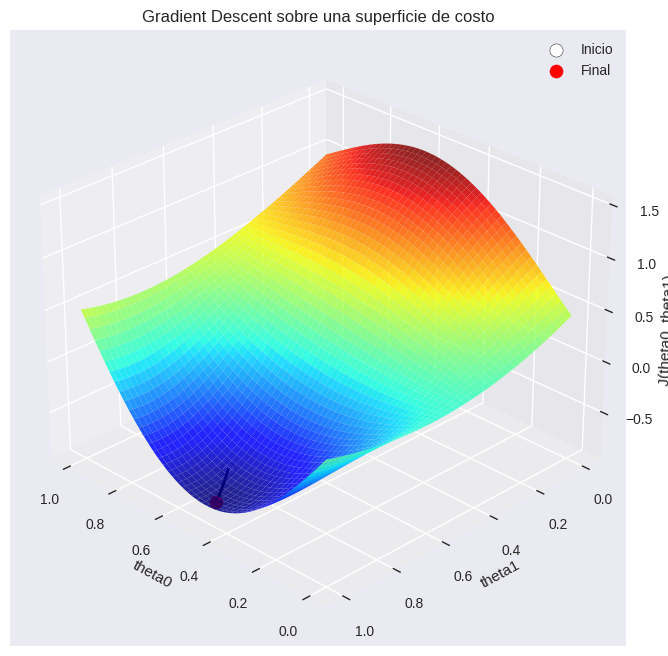

In [11]:
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(T0, T1, Z, cmap='jet', alpha=0.85, linewidth=0)
ax.plot(path[:, 0], path[:, 1], path_z, color='black', marker='x', linewidth=2, markersize=7)
ax.scatter(path[0, 0], path[0, 1], path_z[0], color='white', edgecolor='black', s=90, label='Inicio')
ax.scatter(path[-1, 0], path[-1, 1], path_z[-1], color='red', s=90, label='Final')

ax.set_xlabel('theta0')
ax.set_ylabel('theta1')
ax.set_zlabel('J(theta0, theta1)')
ax.set_title('Gradient Descent sobre una superficie de costo')
ax.view_init(elev=28, azim=135)
ax.legend()

plt.show()

## 5. Curvas de nivel

Esta vista permite ver mejor el desplazamiento en el plano `(theta0, theta1)`.

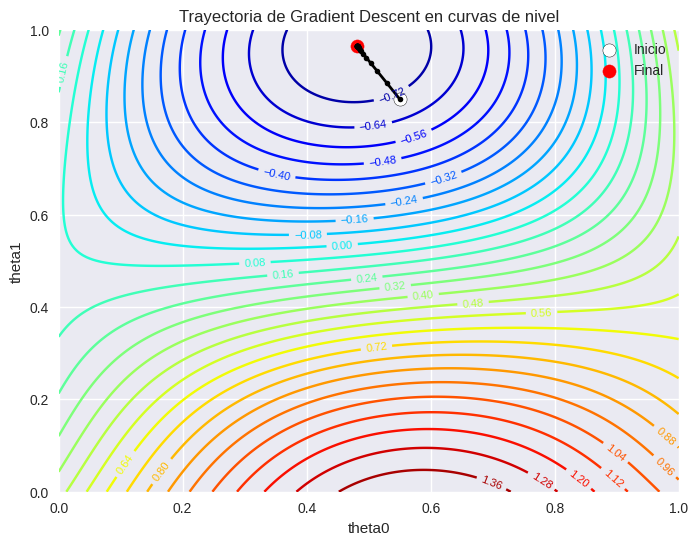

In [12]:
plt.figure(figsize=(8, 6))
contours = plt.contour(T0, T1, Z, levels=30, cmap='jet')
plt.clabel(contours, inline=True, fontsize=8)
plt.plot(path[:, 0], path[:, 1], color='black', marker='o', linewidth=2, markersize=4)
plt.scatter(path[0, 0], path[0, 1], color='white', edgecolor='black', s=90, label='Inicio')
plt.scatter(path[-1, 0], path[-1, 1], color='red', s=90, label='Final')
plt.xlabel('theta0')
plt.ylabel('theta1')
plt.title('Trayectoria de Gradient Descent en curvas de nivel')
plt.legend()
plt.show()

## 6. Evolucion del costo

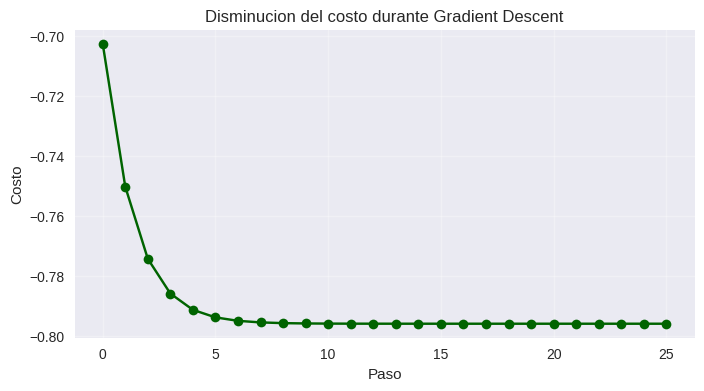

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(history, marker='o', color='darkgreen')
plt.xlabel('Paso')
plt.ylabel('Costo')
plt.title('Disminucion del costo durante Gradient Descent')
plt.grid(True, alpha=0.3)
plt.show()

## 7. Para experimentar

Prueba cambiando:

- `start` para iniciar desde otra zona,
- `learning_rate` para modificar el tamano del paso,
- `steps` para alargar o acortar la trayectoria.